# Justify the 2Dmesh smoothing parameters used in MeshPipeline
- The aim of this step is to output a mesh that is as close an approximation as possible to the original bone. That means removing staircasing that results from image resolution / segmentation / meshing (e.g. ball pivoting).
- Not worried about computation time yet 
- focus on converging towards a reasonable approximation of the surface
- none of these smoothing processes are computationally heavy so aslong as the point count doesn't completely explode we can look for convergence.
- remesh steps will consider computation time

In [2]:
import numpy as np
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt
from tqdm import tqdm
import itertools
import os

from phd_helpers.paths import get_subject_stl_path, get_mesh, avg_edge_length, compute_edge_lengths, get_task_stl_paths, get_info

In [3]:
stl_paths = get_task_stl_paths('CMC')

bone = 'tpm'
subject, sideL = '14548', 'R'
stl_path = get_subject_stl_path(subject, sideL)

#0.5 edge length mesh
#stl_path = get_subject_stl_path("15285", 'R')

mesh = get_mesh(stl_path, bone)
print(avg_edge_length(mesh))

0.36053586


In [47]:
mesh.plot()

Widget(value='<iframe src="http://localhost:49866/index.html?ui=P_0x3743298b0_29&reconnect=auto" class="pyvist…

In [48]:
mesh.smooth_taubin(n_iter=50).plot()

Widget(value='<iframe src="http://localhost:49866/index.html?ui=P_0x3742ce360_30&reconnect=auto" class="pyvist…

# Can i refine the original mesh before smoothing? --- NO ---
 - To give a more flexibility to create a smooth finish

 Turns out no. So smoothness is limited by initial mesh resolution

In [49]:
mesh2 = mesh.subdivide(1, subfilter='linear') # loop and butterfly also bad 
mesh2.smooth_taubin(n_iter=50).plot()

Widget(value='<iframe src="http://localhost:49866/index.html?ui=P_0x374289040_31&reconnect=auto" class="pyvist…

In [50]:
mesh3 = mesh.subdivide_adaptive(max_edge_len=0.2)
mesh3.smooth_taubin(n_iter=50).plot()

Context leak detected, CoreAnalytics returned false


Widget(value='<iframe src="http://localhost:49866/index.html?ui=P_0x374330860_32&reconnect=auto" class="pyvist…

# What about, smooth -> subdivide -> smooth ?
 - looks good but is it actually diffferent to just smoothing?

In [51]:
mesh.smooth_taubin(n_iter=50).subdivide(1).smooth_taubin(n_iter=50).plot()

Widget(value='<iframe src="http://localhost:49866/index.html?ui=P_0x3743335f0_33&reconnect=auto" class="pyvist…

# Try reconstruting the surface then sampling a mesh
 - Terrible if use original mesh
 - Much better if smooth first. Looks really good in some spots but has some wavyness and divots (seem like non-desirable algo artificats) that make it look less smooth than just smoothing in other places, even with smoothing after. Plus adds another complicated step that potentially moves the bone further from the truth, so if not blatant improvement then shouldn't do it.

In [39]:
m0 = mesh.copy(deep=True)
m1 = m0.smooth_taubin(n_iter=50)

pts = pv.PolyData(m1.points)
m2 = pts.reconstruct_surface(nbr_sz=20, sample_spacing=0.2)

In [40]:
m2.smooth_taubin(n_iter=50).plot()

Widget(value='<iframe src="http://localhost:49866/index.html?ui=P_0x37428b7d0_24&reconnect=auto" class="pyvist…

# Justify taubin_iters()
 - Need to include smooth -> subdivide -> smooth
    - Trying surface reconsstruction in addition to this at this point is not worth it because the mesh is already at the desired resolution.

#### Metrics:
 - RMS distance
    - Chose to do RMSD of original mesh points from all smoothed meshes so that the same set of points is always being compared. Otherwise subdividing introduces lots of new points and can make metrics such as AbsMaxD seem like they are much worse implying the surface is worse but the surface is identical, it's actually just that new points were added to a face that is far from the original mesh, misleading... using original mesh points avoids this.
 - Maximum absolute distance - find largest deviation in any of the articulation regions
 - signed distance bias
 - volume change
 - area change
 - Do RMSD and MAD for both cartilage and non cartilage points (effect on contact results is most important consideration)
    - just do points based on original mesh, even though they change (to much computation time and still good estimate)
    - MAYBE scrap this? keep it simple?


 - Considered surface curvature, but this is too mesh dependent especially when mesh starts so coarse - significant local or global changes in curvature are ambiguous. A decrease could indicate a loss of some anatomical features (un desirable) or loss of segnmentation/meshing induced tesselations (desirable).
    - Same with normal deviation.

#### Plan:
 - Smooth bone np.linspace(0, n_iters, n_steps)
 - measure each metric at each step
 - plot metrics against n_iters
 - Check if each metric is correlated to element quality

 - Produce summary table of laplacian_smoothing, taubin_smoothing, taubin_smooth -> subdivide -> ...

### Get point ids of points within 2mm of any articulating bone in any pose

In [ ]:

from phd_helpers.CartilageGeneration import get_min_df_fast
ar_bones = ['mc1', 'mc2', 'tpd', 'sca']
poses = ['adduction','abduction','flexion','extension','pinch','grasp','jar','neutral']
ar_ids = []
for ar_bone in ar_bones:
    ar_mesh = get_mesh(stl_path, ar_bone)
    df = get_min_df_fast(stl_path, bone, ar_bone, mesh, ar_mesh, poses, max_gap=2)
    ar_ids.extend(df['bone_id'].values)
ar_ids = np.unique(ar_ids)

In [134]:
pl = pv.Plotter()
pl.add_mesh(mesh)
pl.add_points(mesh.points[ar_ids])
pl.show()

Widget(value='<iframe src="http://localhost:49866/index.html?ui=P_0x392515cd0_57&reconnect=auto" class="pyvist…

### Effect of smoothing

#### Just smoothing:
 - Although change in overall RMSD and volume is minimal into higher iterations, the change in the surface shape in the areas of  maximum absolute distance appear to be undesirable loss of genuine bone features. So lower number of iterations may be justified.

In [3]:
def compute_smoothing_metrics(og_mesh, mesh_ss, n_iters, return_max_idx=False):
    """
    og_mesh: Original DB mesh
    mesh_ss: mesh to start smoothing from
    n_iters: array of smoothing iterations
    """
    vol = og_mesh.volume
    area = og_mesh.area

    metrics = {
        'Vsmooth': [],
        'Vchange': [],
        'Vchange_pct': [],
        'Asmooth': [],
        'Achange': [],
        'Achange_pct': [],
        'RMSD': [],
        'AbsMaxD': [],
        'MeanDist': [],

        'Vchange_self': [],
        'Vchange_pct_self': [],
        'Achange_self': [],
        'Achange_pct_self': [],
        'RMSD_self': [],
        'AbsMaxD_self': [],
        'MeanDist_self': [],

        'p2p_RMSD_self': [],
        'p2p_AbsMaxD_self': [],
        
    }

    mesh_b = mesh_ss
    for n_iter in n_iters:
        if n_iter == 0:
            mesh_smooth = mesh_ss.copy(deep=True)
        else:
            mesh_smooth = mesh_ss.smooth_taubin(n_iter=n_iter)

        # change relative to og_mesh
        metrics['Vsmooth'].append(mesh_smooth.volume)
        metrics['Vchange'].append(metrics['Vsmooth'][-1] - vol)
        metrics['Vchange_pct'].append(metrics['Vchange'][-1] / vol * 100)

        metrics['Asmooth'].append(mesh_smooth.area)
        metrics['Achange'].append(metrics['Asmooth'][-1] - area)
        metrics['Achange_pct'].append(metrics['Achange'][-1] / area * 100)

        #dists = og_mesh.compute_implicit_distance(mesh_smooth)['implicit_distance']
        _, ps = mesh_smooth.find_closest_cell(og_mesh.points, return_closest_point=True)
        dists = np.linalg.norm(og_mesh.points - ps, axis=1)
        metrics['RMSD'].append(np.sqrt(np.mean(dists**2)))
        metrics['AbsMaxD'].append(np.max(np.abs(dists)))
        max_dist_idx = np.argmax(np.abs(dists))
        metrics['MeanDist'].append(np.mean(dists))

        # change relative to mesh from previous smoothing step
        #dists_self = mesh_smooth.compute_implicit_distance(mesh_b)['implicit_distance']
        _, ps_self = mesh_b.find_closest_cell(mesh_smooth.points, return_closest_point=True)
        dists_self = np.linalg.norm(mesh_smooth.points - ps_self, axis=1)
        metrics['RMSD_self'].append(np.sqrt(np.mean(dists_self**2)))
        metrics['AbsMaxD_self'].append(np.max(np.abs(dists_self)))

        metrics['Vchange_self'].append(metrics['Vsmooth'][-1] - mesh_b.volume)
        metrics['Vchange_pct_self'].append(metrics['Vchange_self'][-1] / mesh_b.volume * 100)

        metrics['Achange_self'].append(metrics['Asmooth'][-1] - mesh_b.area)
        metrics['Achange_pct_self'].append(metrics['Achange_self'][-1] / mesh_b.area * 100)

        metrics['MeanDist_self'].append(np.mean(dists_self))

        # compute distance metrics between each corresponding point for each smoothin step
        points_a = mesh_smooth.points
        points_b = mesh_b.points
        dists_p2p = np.linalg.norm(points_b - points_a, axis=1)
        metrics['p2p_RMSD_self'].append(np.sqrt(np.mean(dists_p2p**2)))
        metrics['p2p_AbsMaxD_self'].append(np.max(dists_p2p))

        mesh_b = mesh_smooth.copy(deep=True)
        del mesh_smooth


    if return_max_idx:
        return metrics, max_dist_idx
    return metrics

### Effect of smooth -> subdivide -> smooth ...?

In [138]:
total_iters = 500
step = 10

initial_iters = np.arange(20, 60+1, step)
subdivides = [1, 2]

iter_subs = np.array(list(itertools.product(initial_iters, subdivides)))
iter_subs = np.concatenate(([[0, 0]], iter_subs))
iter_subs


array([[ 0,  0],
       [20,  1],
       [20,  2],
       [30,  1],
       [30,  2],
       [40,  1],
       [40,  2],
       [50,  1],
       [50,  2],
       [60,  1],
       [60,  2]])

In [139]:

metrics_list = []
for initial_iter, subs in tqdm(iter_subs):
    if initial_iter == 0:
        mesh_ss = mesh.subdivide(subs)
    else:
        mesh_ss = mesh.smooth_taubin(n_iter=initial_iter).subdivide(subs)

    n_iters = np.arange(0, total_iters-initial_iter+1, step)

    m = compute_smoothing_metrics(mesh, mesh_ss, n_iters)
    m['n_iters'] = n_iters + initial_iter
    metrics_list.append(m)
        

100%|██████████| 11/11 [02:28<00:00, 13.50s/it]


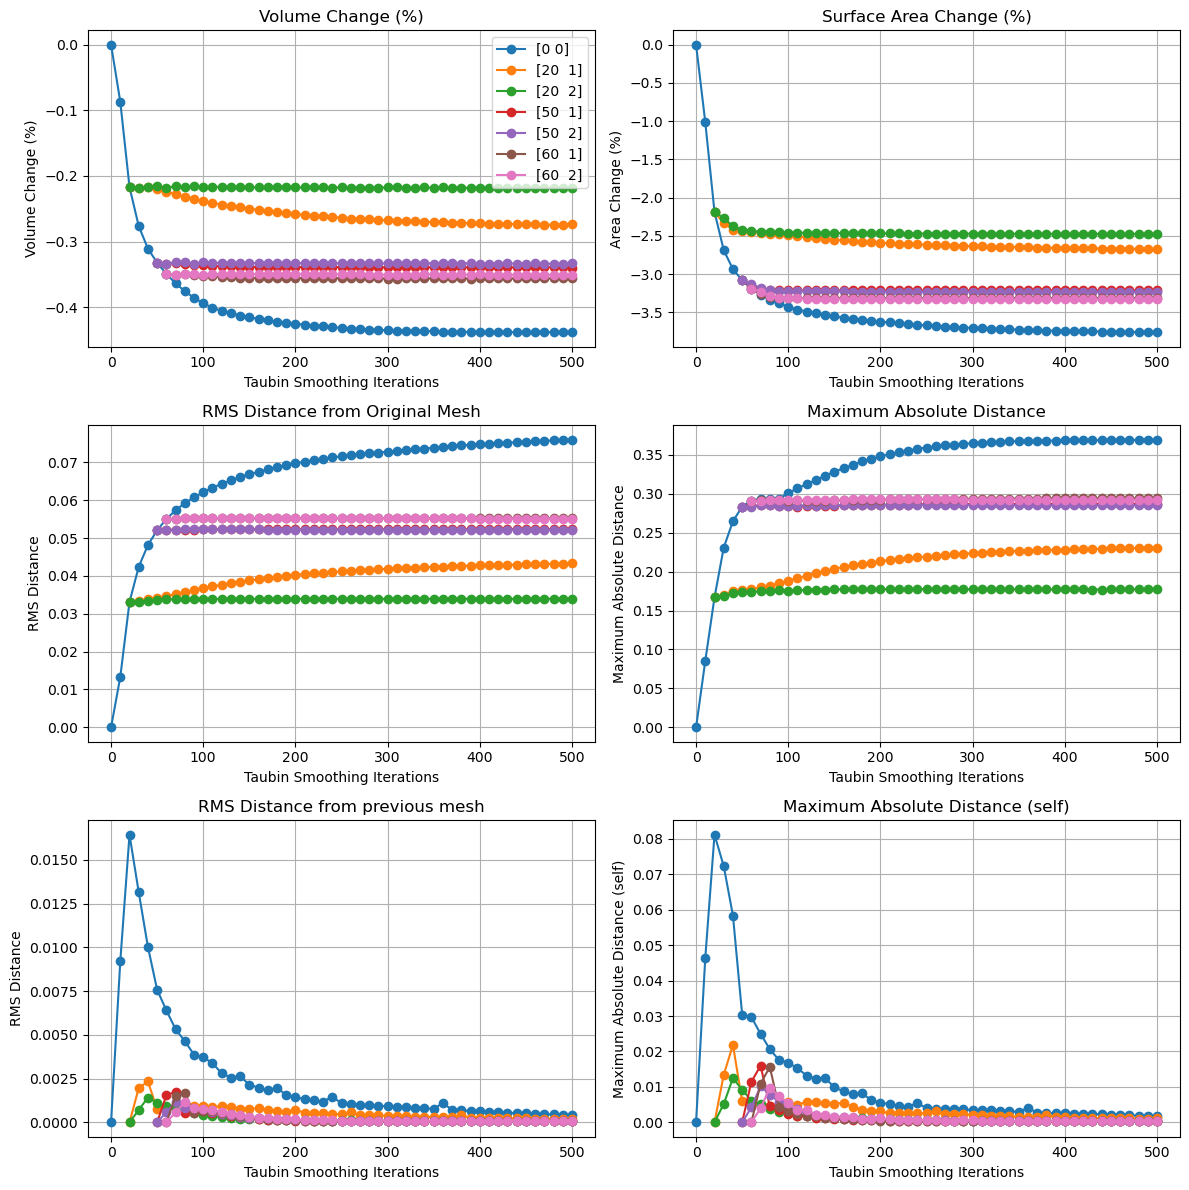

: 

In [ ]:
# select results
iters = [0, 20, 50, 60]
subs = [0, 1, 2]
metric_ids = np.where( np.isin(iter_subs[:, 0], iters) & np.isin(iter_subs[:, 1], subs) )[0]

# plot
fig, ax = plt.subplots(3, 2, figsize=(12, 12))
ax = ax.flatten()

for metric_id in metric_ids:
    metric = metrics_list[metric_id]
    ax[0].plot(metric['n_iters'], metric['Vchange_pct'], marker='o', label=f'{iter_subs[metric_id]}')
    ax[0].set_title('Volume Change (%)')
    ax[0].set_ylabel('Volume Change (%)')

    ax[1].plot(metric['n_iters'], metric['Achange_pct'], marker='o')
    ax[1].set_title('Surface Area Change (%)')
    ax[1].set_ylabel('Area Change (%)')

    ax[2].plot(metric['n_iters'], metric['RMSD'], marker='o')
    ax[2].set_title('RMS Distance from Original Mesh')
    ax[2].set_ylabel('RMS Distance')

    ax[3].plot(metric['n_iters'], metric['AbsMaxD'], marker='o')
    ax[3].set_title('Maximum Absolute Distance')
    ax[3].set_ylabel('Maximum Absolute Distance')

    ax[4].plot(metric['n_iters'], metric['RMSD_self'], marker='o')
    ax[4].set_title('RMS Distance from previous mesh')
    ax[4].set_ylabel('RMS Distance')

    ax[5].plot(metric['n_iters'], metric['AbsMaxD_self'], marker='o')
    ax[5].set_title('Maximum Absolute Distance (self)')
    ax[5].set_ylabel('Maximum Absolute Distance (self)')


for ax_i in ax:
    ax_i.set_xlabel('Taubin Smoothing Iterations')
    ax_i.grid()  

ax[0].legend()
plt.tight_layout()   

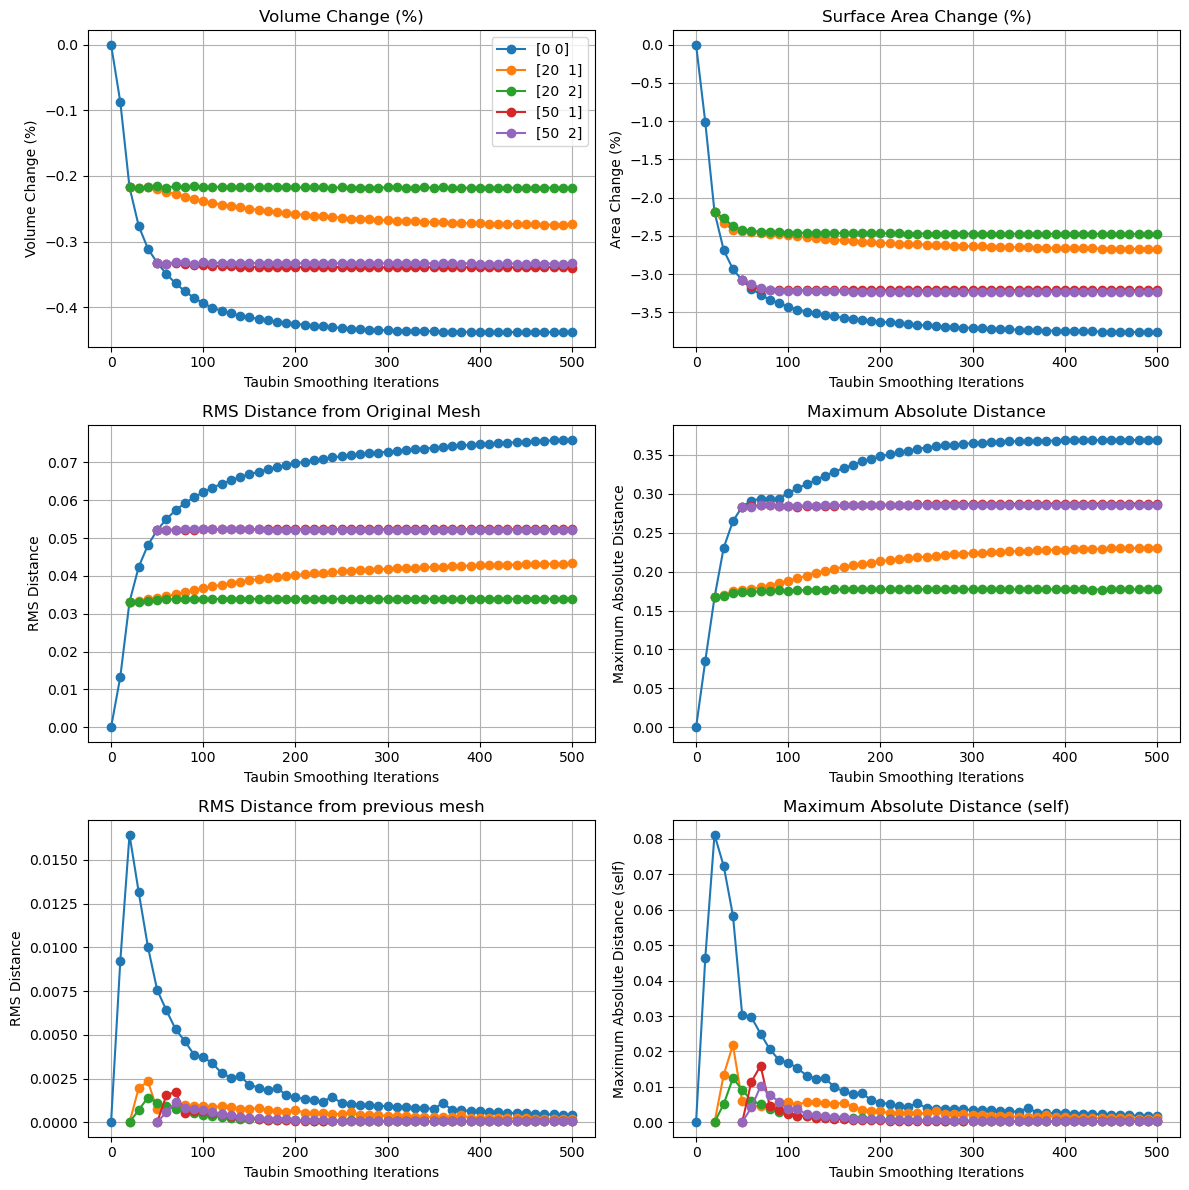

In [ ]:
# select results
iters = [0, 20, 50]
subs = [0, 1, 2]
metric_ids = np.where( np.isin(iter_subs[:, 0], iters) & np.isin(iter_subs[:, 1], subs) )[0]

# plot
fig, ax = plt.subplots(3, 2, figsize=(12, 12))
ax = ax.flatten()

for metric_id in metric_ids:
    metric = metrics_list[metric_id]
    ax[0].plot(metric['n_iters'], metric['Vchange_pct'], marker='o', label=f'{iter_subs[metric_id]}')
    ax[0].set_title('Volume Change (%) from original mesh')
    ax[0].set_ylabel('Volume Change (%)')

    ax[1].plot(metric['n_iters'], metric['Achange_pct'], marker='o')
    ax[1].set_title('Surface Area Change (%) from original mesh')
    ax[1].set_ylabel('Area Change (%)')

    ax[2].plot(metric['n_iters'], metric['RMSD'], marker='o')
    ax[2].set_title('RMS Distance from Original Mesh')
    ax[2].set_ylabel('RMS Distance')

    ax[3].plot(metric['n_iters'], metric['AbsMaxD'], marker='o')
    ax[3].set_title('Maximum Absolute Distance from original mesh')
    ax[3].set_ylabel('Maximum Absolute Distance from original mesh')

    ax[4].plot(metric['n_iters'], metric['RMSD_self'], marker='o')
    ax[4].set_title('RMS Distance from previous mesh')
    ax[4].set_ylabel('RMS Distance')

    ax[5].plot(metric['n_iters'], metric['AbsMaxD_self'], marker='o')
    ax[5].set_title('Maximum Absolute Distance from previous mesh')
    ax[5].set_ylabel('Maximum Absolute Distance from previous mesh')


for ax_i in ax:
    ax_i.set_xlabel('Taubin Smoothing Iterations')
    ax_i.grid()  

ax[0].legend()
plt.tight_layout()   

In [ ]:
pl = pv.Plotter()
pl.add_mesh(mesh)

pl.camera_position = pv.CameraPosition(position=(56.580596782715624, 78.49116426918512, 78.4729835229108),
               focal_point=(74.29787593712469, 73.18902842905602, 82.22527576939808),
               viewup=(0.342562810387439, 0.7061095527930579, -0.6197257622479861))
pl.show()

Widget(value='<iframe src="http://localhost:58731/index.html?ui=P_0x17e9f4200_2&reconnect=auto" class="pyvista…

In [99]:
mesh.smooth_taubin(n_iter=100).plot()

Widget(value='<iframe src="http://localhost:58731/index.html?ui=P_0x3d220b620_11&reconnect=auto" class="pyvist…

In [106]:
pl = pv.Plotter()
pl.add_mesh(mesh.smooth_taubin(n_iter=50).subdivide(2).smooth_taubin(n_iter=100))
pl.add_mesh(mesh.smooth_taubin(n_iter=50), style='wireframe', color='black')
pl.show()

Widget(value='<iframe src="http://localhost:58731/index.html?ui=P_0x168d8ba10_18&reconnect=auto" class="pyvist…

In [21]:
pl = pv.Plotter()
pl.add_mesh(mesh.smooth_taubin(n_iter=40).subdivide(1).smooth_taubin(n_iter=50))

pl.show()

Widget(value='<iframe src="http://localhost:60044/index.html?ui=P_0x33db3c260_8&reconnect=auto" class="pyvista…

### Effect of smoothing after subdivision
 - Going to look at the direction of the normals on a curved patch of mesh

 - maybe just zooming in very close on curved area of subdivided mesh and showing how surface changes with smoothing would be most effective?
    - maybe also show simple example with a sphere to demonstrate the effect it is having

#### Not bad
- could first show that mesh2a is the identical surface to mesh1 just with more cells
   - then show this to demonstrate increase in resolution
   - and show plots of metrics to demonstrate it hasn't affected fidelity
       - doesn't remove features just very local balancing of points and edges increasing resolution
       - this avoids problem of furture remesh trying to replicate coarse shape rather than "true" shape
       - also probably some papers on how smoothness enables higher element quality - or maybe I can quickly demonstrate it?
           - demonstrate both coarse shape replication and element quality effect with 2Dmesh!!!!!
           - also check if lumpy bits are still there after dense remesh on just smooth mesh

In [42]:
p = np.array([81, 65, 80]) # point on curved patch of bone
idx = mesh.find_closest_point(p)

n_iter = 50
sub = 2
mesh1 = mesh.smooth_taubin(n_iter=n_iter)
mesh2a = mesh.smooth_taubin(n_iter=n_iter).subdivide(sub)
mesh2b = mesh.smooth_taubin(n_iter=n_iter).subdivide(sub).smooth_taubin(n_iter=100)

p1 = mesh1.find_closest_point(p)
p2 = mesh2a.find_closest_point(mesh1.points[p1])
ns = np.array(list(mesh2a.point_neighbors_levels(p2, 1))[0])

ps2a = mesh2a.points[ns]
ps2b = mesh2b.points[ns]
normals2a = mesh2a.compute_normals(point_normals=True, cell_normals=False)['Normals'][ns]
normals2b = mesh2b.compute_normals(point_normals=True, cell_normals=False)['Normals'][ns]



In [ ]:
pl = pv.Plotter()
pl.add_mesh(mesh2b)
pl.add_mesh(mesh1, style='wireframe', color='black')

#pl.add_arrows(ps2a, normals2a, mag=1, color='blue')
#pl.add_arrows(ps2b, normals2b, mag=1, color='red')

pl.camera_position = pv.CameraPosition(position=(81.45126216332721, 66.8371492428253, 79.26034844971738),
               focal_point=(79.81872011106553, 65.51146562362999, 84.95136776870991),
               viewup=(0.16863950718793888, -0.9695681269831339, -0.17747778383174287))
pl.show()

Widget(value='<iframe src="http://localhost:60044/index.html?ui=P_0x356c4c470_20&reconnect=auto" class="pyvist…

### Summary so far: 

 - smoothing helps to remove staircasing, taubin smoothing preserves volume, too much loses genuine features.
 - still limitation of coarse cells, subdividing then smoothing again does not effect fidelity but does improve resolution.  
       - can't subdivide first cos then it holds on to staircasing 
       - therefore lets pick a smoothing level that looks good (eliminates staircasing as much as possible) but doesn't deviate beyond a chosen limit accross all subjects. (maybe choose max devition based on measurement of idetified features on some meshes a +/- maybe image resolution? and choose the value based on a % of that? - how big does a feature need to be to not be hidden by stiarcasing / coarseness of mesh?, needs multiple noticable faces between extremes of the feature. Therefore, MaxAbsD = ?% of 2*avg_edge_length)
             - But need change to be between half an edge length and full edge length to remove staircase? or not cos not actaully staircase
             - ct resolution in transverse plane was between 0.2 to 0.4 mm so to account for this expect similar magnitude change to happen. Any processs that manages to correct for this in any way would need to make similar magnitude changes but any chages significantly higher than this would indicate loss of genuine bone features.

       - and look at if n subdivision converges before n points gets too large.



### How much smoothing?

- show an image of typical 1 edge length deep staircasing due to resolution, then show two edge length deep "feature" and annotate movement of point at centre of feature needed for feature to be lost
    - preface by showing how features are lost during smoothing by the fig described in overleaf? of crevice with implicit distance map from original unsmoothed
    - stress that this is just attempt to better approximate suitable max value, it is possible for combinations of face sizes and orientations to form features that do not adhere to this "rule".

In [4]:
mesh.plot()

Widget(value='<iframe src="http://localhost:61878/index.html?ui=P_0x302d76ae0_0&reconnect=auto" class="pyvista…

In [5]:
L_avg = avg_edge_length(mesh)
L_max = compute_edge_lengths(mesh).max()

print(f'Average edge length: {L_avg:.4f} mm')
print(f'max edge length: {L_max:.4f} mm')

Average edge length: 0.3605 mm
max edge length: 0.7469 mm


In [6]:
2.5 * L_avg

np.float32(0.90133965)

In [7]:
mesh.length

27.885068637375834

In [8]:
0.3 / mesh.length

0.010758445815618115

In [111]:
cols = ['subject', 'sideL', 'edge_length', 'volume']
data = []
for stl_path in stl_paths:
    subject, sideL = get_info(stl_path)
    msh = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(msh)
    V = msh.volume
    data.append(
        [subject, sideL, L, V]
    )
df = pd.DataFrame(data, columns=cols)

group05 = df[df['edge_length']>0.5]
group04 = df[(df['edge_length']>0.43) & (df['edge_length']<0.5)]
group03 = df[df['edge_length']<0.43]

No relationship with volume but maybe related to ct scan resolution as they varied in transverse plane from 0.2 -> 0.4 mm
(Groups are consistent accross all bones for each subject, but bone specific averages vary)
(improve this plot at write up to show transparent bands around each group indicating max and min accross all bones)

Average edge length
Group 1: 0.37 mm
Group 2: 0.44 mm
Group 3: 0.52 mm


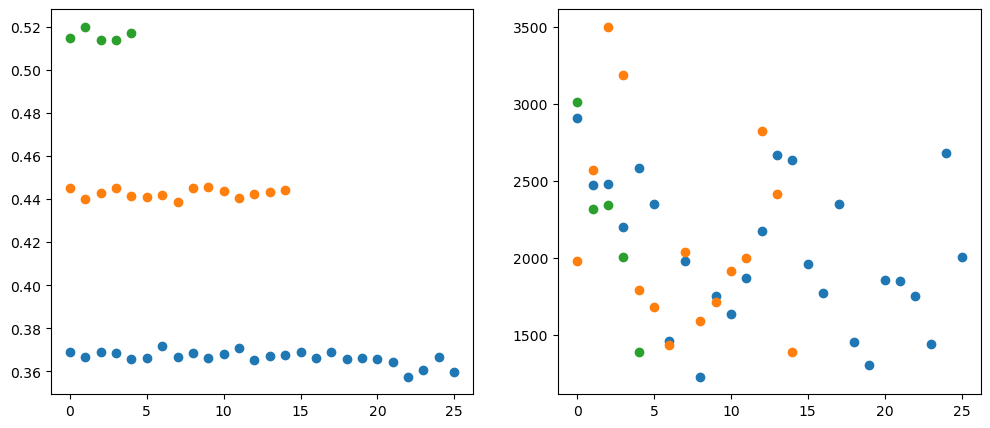

In [112]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

print('No relationship with volume but maybe related to ct scan resolution as they varied in transverse plane from 0.2 -> 0.4 mm')
print('(Groups are consistent accross all bones for each subject, but bone specific averages vary)')
print('(improve this plot at write up to show transparent bands around each group indicating max and min accross all bones)')
print(f'\nAverage edge length')
for i, group in enumerate([group03, group04, group05], start=1):
    print(f'Group {i}: {group['edge_length'].mean():.2f} mm')
    ax[0].scatter(np.arange(len(group)), group['edge_length'])
    ax[1].scatter(np.arange(len(group)), group['volume'])

plt.show()

In [81]:
b = 'tpm'
i = 1
mesh03 = get_mesh(get_subject_stl_path(group03.subject.iloc[i], group03.sideL.iloc[i]), b)
mesh04 = get_mesh(get_subject_stl_path(group04.subject.iloc[i], group04.sideL.iloc[i]), b)
mesh05 = get_mesh(get_subject_stl_path(group05.subject.iloc[i], group05.sideL.iloc[i]), b)

In [ ]:
mesh03.plot()
mesh05.plot()

#### Compute metrics for taubin smoothing for all subjects and all bones

In [ ]:
bones = np.array(['rad', 'uln', 'sca', 'lun', 'trq', 'pis', 'tpd',
                        'tpm', 'cap', 'ham', 'mc1', 'mc2', 'mc3', 'mc4', 'mc5'])

n_iters = np.hstack( (np.arange(0, 110, 10), np.arange(150, 550, 50)) )

for sp in tqdm(stl_paths):
    metrics_list = []
    for bn in bones:
        #print(bn)
        msh = get_mesh(sp, bn)
        mets = compute_smoothing_metrics(msh, msh, n_iters)

        sbjt, sdL = get_info(sp)

        mets['edge_length'] = [avg_edge_length(msh)] * len(n_iters)
        mets['subject'], mets['sideL'] = [sbjt]*len(n_iters), [sdL] * len(n_iters)
        mets['bone'] = [bn] * len(n_iters)
        mets['n_iter'] = n_iters

        metrics_list.append(mets)
    #pd.concat([pd.DataFrame(x) for x in metrics_list]).to_csv(f'metric_dfs/smooth_taubin/{sbjt}{sdL}.csv', index=False)
        

100%|██████████| 2/2 [02:17<00:00, 68.92s/it]


In [4]:
import os
metric_df = pd.concat([pd.read_csv('metric_dfs/smooth_taubin/'+x) for x in os.listdir('metric_dfs/smooth_taubin') if '.csv' in x])
metric_df['AbsMaxD_norm'] = metric_df['AbsMaxD'] / metric_df['edge_length']
metric_df['RMSD_norm'] = metric_df['RMSD'] / metric_df['edge_length']
metric_df

,Vsmooth,Vchange,Vchange_pct,Asmooth,Achange,Achange_pct,RMSD,AbsMaxD,MeanDist,Vchange_self,...,MeanDist_self,p2p_RMSD_self,p2p_AbsMaxD_self,edge_length,subject,sideL,bone,n_iter,AbsMaxD_norm,RMSD_norm
0,20109.850333,0.000000,0.000000,5695.063384,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.476598,14873,R,rad,0,0.000000,0.000000
1,20090.061844,-19.788489,-0.098402,5638.052097,-57.011287,-1.001065,0.016277,0.107614,-0.000415,-19.788489,...,-0.001493,0.070710,0.164840,0.476598,14873,R,rad,10,0.225796,0.034152
2,20062.297678,-47.552655,-0.236464,5567.302025,-127.761359,-2.243370,0.042332,0.270192,-0.001414,-27.764167,...,-0.001584,0.088042,0.228679,0.476598,14873,R,rad,20,0.566919,0.088822
3,20052.086562,-57.763771,-0.287241,5545.667798,-149.395586,-2.623247,0.052305,0.341896,-0.001307,-10.211116,...,0.000330,0.032246,0.120075,0.476598,14873,R,rad,30,0.717367,0.109746
4,20047.060390,-62.789943,-0.312235,5536.421269,-158.642115,-2.785608,0.057437,0.388984,-0.001088,-5.026172,...,0.000151,0.019879,0.092184,0.476598,14873,R,rad,40,0.816168,0.120515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,2757.205115,0.066729,0.002420,1458.627837,-16.642450,-1.128095,0.047306,0.383728,0.003055,-0.042680,...,0.000074,0.005368,0.017232,0.398321,50000,R,mc5,300,0.963363,0.118764
281,2757.178290,0.039903,0.001447,1458.480459,-16.789828,-1.138085,0.047821,0.383596,0.003074,-0.026825,...,0.000061,0.003956,0.010765,0.398321,50000,R,mc5,350,0.963033,0.120055
282,2757.157187,0.018801,0.000682,1458.349732,-16.920555,-1.146946,0.048215,0.383933,0.003088,-0.021103,...,0.000057,0.003464,0.010214,0.398321,50000,R,mc5,400,0.963878,0.121045
283,2757.145097,0.006711,0.000243,1458.257774,-17.012513,-1.153179,0.048493,0.384892,0.003094,-0.012090,...,0.000048,0.002695,0.008340,0.398321,50000,R,mc5,450,0.966285,0.121744


In [54]:
its = 50
sub_group = metric_df[(metric_df['n_iter']==its)]
sub_Vmax = sub_group['Vchange_pct']
sub_RMSDmax = sub_group['RMSD']
sub_RMSDmaxNorm = sub_group['RMSD_norm']
sub_AbsMax = sub_group['AbsMaxD']
sub_AbsMaxNorm = sub_group['AbsMaxD_norm']

sub_Vmax_self = sub_group['Vchange_pct_self']
sub_RMSDmax_self = sub_group['RMSD_self']

- Can almost see that vol change and rmsd are in little groups (assume they are subjects)
- Whereas AbsMaxD is not
- That's because RMSD is global, influcenced by overall bone shape - smoooth or sharper
- whereas AbsMaxD is local, influenced by presence of one sharp feature, which can be present on any bone of any subject
- also shows that subject to subject variation is more dominant that bone to bone variation on global measures.

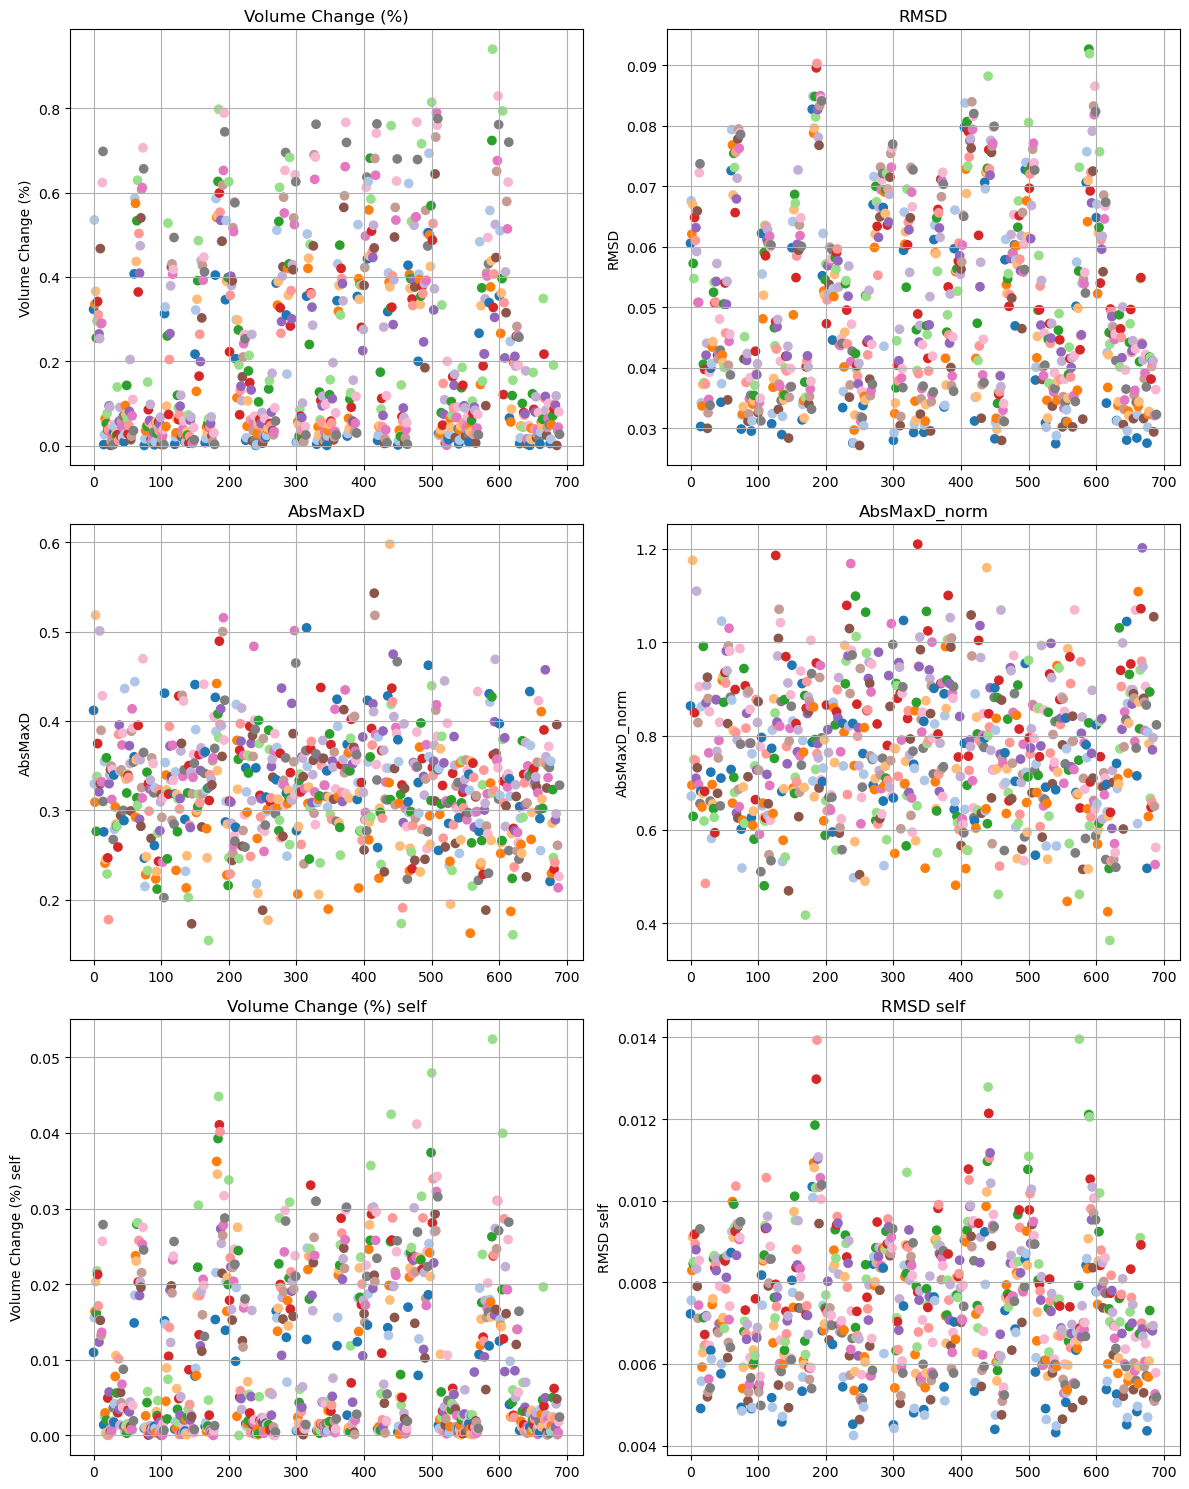

In [55]:
bones = np.array(['rad', 'uln', 'sca', 'lun', 'trq', 'pis', 'tpd',
                        'tpm', 'cap', 'ham', 'mc1', 'mc2', 'mc3', 'mc4', 'mc5'])

# plot
fig, ax = plt.subplots(3, 2, figsize=(12, 15))
ax = ax.flatten()

palette = list(plt.cm.tab20.colors[:15])
color_map = {bone: palette[i] for i, bone in enumerate(bones)}

point_colors = sub_group['bone'].map(color_map)

x = np.arange(len(sub_group))
ax[0].scatter(x, np.abs(sub_Vmax), c=point_colors, marker='o')
ax[0].set_title('Volume Change (%)')
ax[0].set_ylabel('Volume Change (%)')

ax[1].scatter(x, sub_RMSDmax, c=point_colors, marker='o')
ax[1].set_title('RMSD')
ax[1].set_ylabel('RMSD')

ax[2].scatter(x, sub_AbsMax, c=point_colors, marker='o')
ax[2].set_title('AbsMaxD')
ax[2].set_ylabel('AbsMaxD')

ax[3].scatter(x, sub_AbsMaxNorm, c=point_colors, marker='o')
ax[3].set_title('AbsMaxD_norm')
ax[3].set_ylabel('AbsMaxD_norm')

ax[4].scatter(x, np.abs(sub_Vmax_self), c=point_colors, marker='o')
ax[4].set_title('Volume Change (%) self')
ax[4].set_ylabel('Volume Change (%) self')

ax[5].scatter(x, sub_RMSDmax_self, c=point_colors, marker='o')
ax[5].set_title('RMSD self')
ax[5].set_ylabel('RMSD self')


for ax_i in ax:
    ax_i.grid()  

plt.tight_layout()   

In [56]:
metric_df[(metric_df['n_iter']==its)&(metric_df['AbsMaxD_norm']>1.2)]

,Vsmooth,Vchange,Vchange_pct,Asmooth,Achange,Achange_pct,RMSD,AbsMaxD,MeanDist,Vchange_self,...,MeanDist_self,p2p_RMSD_self,p2p_AbsMaxD_self,edge_length,subject,sideL,bone,n_iter,AbsMaxD_norm,RMSD_norm
119,1685.412568,1.804023,0.107152,802.168031,-17.578955,-2.144437,0.048919,0.437472,0.002816,-0.025502,...,0.000359,0.013822,0.054826,0.361591,50053,R,tpd,50,1.209852,0.135287
157,3536.455794,4.121441,0.116678,1412.913165,-25.070994,-1.743482,0.043907,0.457335,0.031144,0.176329,...,0.005200,0.013851,0.064413,0.380504,50020,R,cap,50,1.201918,0.115392


In [48]:
metric_df[(metric_df['n_iter']==its)&(metric_df['bone']=='tpm')&(metric_df['RMSD_self']>0.009)]

,Vsmooth,Vchange,Vchange_pct,Asmooth,Achange,Achange_pct,RMSD,AbsMaxD,MeanDist,Vchange_self,...,MeanDist_self,p2p_RMSD_self,p2p_AbsMaxD_self,edge_length,subject,sideL,bone,n_iter,AbsMaxD_norm,RMSD_norm
139,1385.420183,-2.946916,-0.212258,697.711369,-17.135707,-2.397115,0.068367,0.408458,0.005569,-0.113546,...,0.000473,0.015110,0.044790,0.516977,14827,L,tpm,60,0.790090,0.132243
139,2307.175056,-13.561560,-0.584364,1047.412108,-53.948860,-4.898381,0.096634,0.416659,0.004580,-0.720133,...,-0.000017,0.018211,0.055095,0.519971,14727,R,tpm,60,0.801312,0.185845
139,2997.213559,-12.810594,-0.425598,1237.755946,-41.987075,-3.280899,0.077896,0.448492,0.003506,-0.701351,...,0.000039,0.015551,0.051223,0.514855,15358,R,tpm,60,0.871104,0.151298


In [ ]:
# low and high of rmsd convergence 
# naturally more sharp bone is further because it has more sharp features that can still be smoothed further (undesirable)
# but smooth surfaces of both bones show satisfactory level of staircase removal

get_mesh(get_subject_stl_path('50006', 'R'), 'tpm').smooth_taubin(n_iter=its).plot() # low
get_mesh(get_subject_stl_path('14727', 'R'), 'tpm').smooth_taubin(n_iter=its).plot() # high

Widget(value='<iframe src="http://localhost:49484/index.html?ui=P_0x351caba10_14&reconnect=auto" class="pyvist…

Widget(value='<iframe src="http://localhost:49484/index.html?ui=P_0x342265280_15&reconnect=auto" class="pyvist…

In [57]:
# tpms at opposite ends of the AbsMaxD_norm scale look equally smoothed - so use same value for all 
# - plus reasoning on overleaf

get_mesh(get_subject_stl_path('50049', 'R'), 'tpm').smooth_taubin(n_iter=its).plot() 
get_mesh(get_subject_stl_path('50049', 'R'), 'tpm').smooth_taubin(n_iter=40).plot()
#get_mesh(get_subject_stl_path('50017', 'L'), 'tpm').smooth_taubin(n_iter=its).plot()

Widget(value='<iframe src="http://localhost:49484/index.html?ui=P_0x330e88890_12&reconnect=auto" class="pyvist…

Widget(value='<iframe src="http://localhost:49484/index.html?ui=P_0x330e8b6e0_13&reconnect=auto" class="pyvist…

# I think all of the following on subdiving then smoothing might just be have to be mentioned briefly in main write up and maybe more thoroughly in an appendix
 - Can reference Taubin paper to show that it is valid option sometimes used, but given fidelity is of most importance rather than visual appeal it seems risky to apply more processing and smoothing, don't want to lose / create features that should / shouldn't be there.
 - Hard to justify given that all subdividing levels barely change the surface relative to the original mesh but going dow to 0.075 edge length makes the bone look like its covered in dimples. Plus some meshes have longer edge length so maybe they get dimples sooner?
     - wonder if dimpling from too many subdivides really "bakes in" the remenants of the staircasing and effects future remeshing - even if its a coarser remesh?
 - Also it will have the effect of smoothing out sharp features, maybe adds ~10% more to AbsMaxD
 - just seems extra and easy to question
 - check if it influences height field of cartilage in the next step
     - Show if influence is negligable then justify not doing it. Beacuse this is very fine detail so irrelevant unless it affects actual contact surface, which is cartilage!!!!!!!!!!



#### How many subdivides?
 - mention n cells and equivalent n equilateral tets to justify subdivision limit (i.e. pick n cells number that is orders of magnitude higher than any potential final mesh so final mesh isn't limited by this one)
 - At this point not worried about computation time, that is taken care of in cartilage generation step
    - some worry about computation time - need to ensure dense mesh doesn't significantly slow remeshing needed for given application
 - Only compuation limit to worry about is memory
 - will have to use final mesh (or maybe cartilage) size to inform n subdivisions and show that remesh step is independent of this step?
    - or show the subdividing converges itself

In [86]:
# might be better to use adaptive edge length so all end up the same resolution

ledge = 0.075 # max edge length of 0.075 gives ~850,000 cells
# small edge length group
print(
    avg_edge_length(mesh.smooth_taubin(n_iter=50).subdivide_adaptive(max_edge_len=ledge))  
    )

# large edge length group
print(
    avg_edge_length(get_mesh(get_subject_stl_path("15285", 'R'), 'tpm').smooth_taubin(n_iter=50).subdivide_adaptive(max_edge_len=ledge))
    )

0.04757658
0.051397815


In [ ]:
# ran this in separate script - subdivide_metrics_multiprocess_stupid.py

bones = np.array(['rad', 'uln', 'sca', 'lun', 'trq', 'pis', 'tpd',
                        'tpm', 'cap', 'ham', 'mc1', 'mc2', 'mc3', 'mc4', 'mc5'])

ledges = [ # max_edge_length
    0.3,  # avg_edge_length ~0.20mm    ~55,000  cells
    0.15, # avg_edge_length ~0.10mm    ~220,000 cells
    0.075 # avg_edge_length ~0.05mm    ~850,000 cells
]

its = 50
n_iters = np.array([50, 60, 70, 80, 90, 100, 150, 200]) 
n_iters -= its

for sp in tqdm(stl_paths[:1]):
    print(sp.parent.name)
    metrics_list = []
    for bn in bones:
        msh = get_mesh(sp, bn)
        for Ledge in tqdm(ledges):
            
            msh_ss = msh.smooth_taubin(n_iter=its).subdivide_adaptive(max_edge_len=Ledge)

            mets = compute_smoothing_metrics(msh, msh_ss, n_iters)

            sbjt, sdL = get_info(sp)

            mets['n_iter'] = n_iters + its
            mets['max_edge_length'] = [Ledge] * len(n_iters)
            mets['edge_length'] = [avg_edge_length(msh_ss)] * len(n_iters)
            mets['subject'], mets['sideL'] = [sbjt]*len(n_iters), [sdL] * len(n_iters)
            mets['bone'] = [bn] * len(n_iters)

            metrics_list.append(mets)
    #pd.concat([pd.DataFrame(x) for x in metrics_list]).to_csv(f'metric_dfs/subdivide/{sbjt}{sdL}.csv', index=False)
        

  0%|          | 0/1 [00:00<?, ?it/s]

50037


100%|██████████| 1/1 [29:49<00:00, 1789.05s/it]


In [5]:
metric_df_sub = pd.concat([pd.read_csv('metric_dfs/subdivide_stupid/'+x) for x in os.listdir('metric_dfs/subdivide_stupid') if '.csv' in x])
metric_df_sub['AbsMaxD_norm'] = metric_df_sub['AbsMaxD'] / metric_df_sub['edge_length']
metric_df_sub['RMSD_norm'] = metric_df_sub['RMSD'] / metric_df_sub['edge_length']
metric_df_sub

,Vsmooth,Vchange,Vchange_pct,Asmooth,Achange,Achange_pct,RMSD,AbsMaxD,MeanDist,Vchange_self,...,p2p_RMSD_self,p2p_AbsMaxD_self,n_iter,max_edge_length,edge_length,subject,sideL,bone,AbsMaxD_norm,RMSD_norm
0,20044.859486,-64.990847,-0.323179,5531.416389,-163.646995,-2.873489,0.060608,0.411866,0.047882,0.000000,...,0.000000,0.000000,50,0.300,0.190038,14873,R,rad,2.167278,0.318924
1,20044.563508,-65.286825,-0.324651,5529.458940,-165.604444,-2.907860,0.060693,0.416007,0.047936,-0.295978,...,0.007394,0.035762,60,0.300,0.190038,14873,R,rad,2.189070,0.319370
2,20044.783863,-65.066470,-0.323555,5528.359967,-166.703417,-2.927156,0.060793,0.430659,0.047999,0.220355,...,0.011313,0.049030,70,0.300,0.190038,14873,R,rad,2.266172,0.319900
3,20044.728168,-65.122165,-0.323832,5528.023822,-167.039563,-2.933059,0.060848,0.444513,0.048026,-0.055695,...,0.006690,0.031149,80,0.300,0.190038,14873,R,rad,2.339071,0.320190
4,20044.285720,-65.564613,-0.326032,5527.767834,-167.295550,-2.937554,0.060883,0.451442,0.048038,-0.442449,...,0.004920,0.023360,90,0.300,0.190038,14873,R,rad,2.375532,0.320371
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,2757.891693,0.753307,0.027322,1462.287540,-12.982747,-0.880025,0.032323,0.331561,0.022762,0.004885,...,0.001439,0.009586,80,0.075,0.046853,50000,R,mc5,7.076608,0.689887
356,2757.837639,0.699253,0.025362,1462.178249,-13.092038,-0.887433,0.032324,0.333176,0.022749,-0.054054,...,0.001520,0.007857,90,0.075,0.046853,50000,R,mc5,7.111075,0.689895
357,2757.892059,0.753672,0.027335,1462.122811,-13.147475,-0.891191,0.032317,0.332804,0.022753,0.054420,...,0.001413,0.005568,100,0.075,0.046853,50000,R,mc5,7.103138,0.689756
358,2757.854936,0.716550,0.025989,1461.897030,-13.373257,-0.906495,0.032315,0.335093,0.022739,-0.037123,...,0.003019,0.015996,150,0.075,0.046853,50000,R,mc5,7.151991,0.689711


#### This doesn't contain all the information I need...
 - Can use this to determine the number of iterations each n subdivides needs to converge 
 - Once the number of smoothing iterations after subdivision has been established - need to reun another script that looks at difference between the subdivided meshes to see if they converge...

#### N iterations needed for each n subdivide to converge
 - smoothing doesn't change points so can look at iterations needed for individual points to settle

#### Messed up again...
 - can't look for convergence with n iterations by lookin at the _self metrics because I went from jumps of 10 to jumps of 50 between smoothing iters, so from 100 to 150 the value gets big again instead of continuing to converge
- will have to look at 50 -> 100 -> 150 -> 200

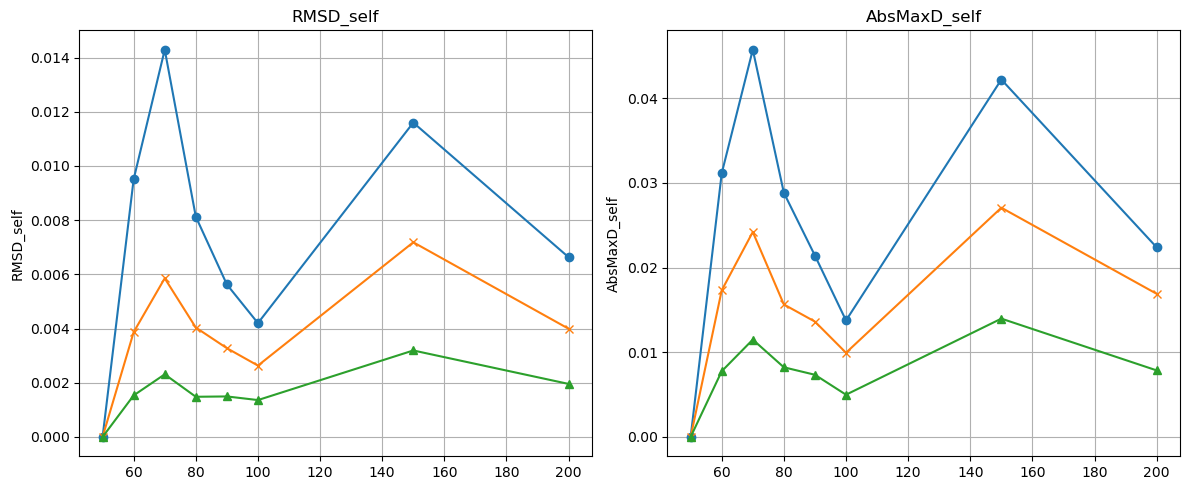

In [11]:
bones = np.array(['rad', 'uln', 'sca', 'lun', 'trq', 'pis', 'tpd',
                        'tpm', 'cap', 'ham', 'mc1', 'mc2', 'mc3', 'mc4', 'mc5'])

subdf = metric_df_sub[(metric_df_sub['subject'].astype(str)==subject) & (metric_df_sub['bone']=='tpm')]
sub_RMSD_p2p = subdf['p2p_RMSD_self']
sub_AbsMax_p2p = subdf['p2p_AbsMaxD_self']


# plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax = ax.flatten()

palette = list(plt.cm.tab20.colors[:15])
color_map = {bone: palette[i] for i, bone in enumerate(bones)}

point_colors = subdf['bone'].map(color_map)


ledges = [0.3, 0.15, 0.075]
markers = ['o', 'x', '^']

for i, ledge in enumerate(ledges):
    x = subdf['n_iter'][subdf['max_edge_length']==ledge]

    ax[0].plot(x, subdf['p2p_RMSD_self'][subdf['max_edge_length']==ledge], marker=markers[i])
    ax[0].set_title('RMSD_self')
    ax[0].set_ylabel('RMSD_self')

    ax[1].plot(x, subdf['p2p_AbsMaxD_self'][subdf['max_edge_length']==ledge], marker=markers[i])
    ax[1].set_title('AbsMaxD_self')
    ax[1].set_ylabel('AbsMaxD_self')


for ax_i in ax:
    ax_i.grid()  

plt.tight_layout()   

In [15]:
subdf

,Vsmooth,Vchange,Vchange_pct,Asmooth,Achange,Achange_pct,RMSD,AbsMaxD,MeanDist,Vchange_self,...,p2p_RMSD_self,p2p_AbsMaxD_self,n_iter,max_edge_length,edge_length,subject,sideL,bone,AbsMaxD_norm,RMSD_norm
0,9690.552957,-41.615482,-0.427608,3434.016229,-137.854674,-3.859453,0.057879,0.309660,0.044814,0.000000,...,0.000000,0.000000,50,0.300,0.184316,14548,R,rad,1.680049,0.314022
1,9690.325879,-41.842560,-0.429941,3432.533422,-139.337481,-3.900966,0.057982,0.311749,0.044884,-0.227078,...,0.008990,0.033047,60,0.300,0.184316,14548,R,rad,1.691382,0.314580
2,9690.272757,-41.895682,-0.430487,3431.654898,-140.216005,-3.925562,0.058180,0.311485,0.045007,-0.053121,...,0.014006,0.052677,70,0.300,0.184316,14548,R,rad,1.689955,0.315654
3,9690.152021,-42.016418,-0.431727,3431.170527,-140.700376,-3.939123,0.058368,0.317691,0.045106,-0.120737,...,0.008103,0.030948,80,0.300,0.184316,14548,R,rad,1.723624,0.316672
4,9689.882735,-42.285704,-0.434494,3430.778570,-141.092333,-3.950096,0.058547,0.326965,0.045201,-0.269286,...,0.005538,0.020528,90,0.300,0.184316,14548,R,rad,1.773942,0.317642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,2248.609762,-15.342508,-0.677687,1313.809594,-60.889755,-4.429314,0.060483,0.356585,0.048046,0.005040,...,0.001506,0.009397,80,0.075,0.046820,14548,R,mc5,7.616061,1.291828
356,2248.565685,-15.386585,-0.679634,1313.668453,-61.030896,-4.439581,0.060501,0.357999,0.048052,-0.044077,...,0.001478,0.006419,90,0.075,0.046820,14548,R,mc5,7.646270,1.292208
357,2248.607925,-15.344345,-0.677768,1313.591366,-61.107983,-4.445189,0.060513,0.359789,0.048070,0.042240,...,0.001347,0.005341,100,0.075,0.046820,14548,R,mc5,7.684514,1.292467
358,2248.579105,-15.373165,-0.679041,1313.339177,-61.360172,-4.463534,0.060563,0.363725,0.048105,-0.028820,...,0.003094,0.014585,150,0.075,0.046820,14548,R,mc5,7.768573,1.293517


## New plan because below shows that refining too much makes mesh dimply
- check if subdivide to 0.3 influences cartilage height field (in remesh-box.ipynb)
     - If influence is negligable then justify not doing it. Beacuse this is very fine detail so irrelevant unless it affects actual contact surface, which is cartilage
      - didn't do this... just did below instead and wrote decent argument in overleaf

In [20]:
mesh.smooth_taubin(n_iter=50).plot()
mesh.smooth_taubin(n_iter=50).subdivide_adaptive(max_edge_len=0.3).smooth_taubin(n_iter=200).plot()
mesh.smooth_taubin(n_iter=50).subdivide_adaptive(max_edge_len=0.075).smooth_taubin(n_iter=200).plot()

Widget(value='<iframe src="http://localhost:51807/index.html?ui=P_0x378c97920_13&reconnect=auto" class="pyvist…

Widget(value='<iframe src="http://localhost:51807/index.html?ui=P_0x378c97800_14&reconnect=auto" class="pyvist…

Widget(value='<iframe src="http://localhost:51807/index.html?ui=P_0x378d05730_15&reconnect=auto" class="pyvist…

## Run 2Dmesh for all subjects
 - Then measure difference between resulting 2Dmesh of the two options
#### Run 1:
 - mesh.smooth_taubin(50)
 - all cells 0.2 mm
#### Run 2:
 - mesh.smooth_taubin(50).subdivide(1).smooth_taubin(200)
 - all cells 0.2 mm 

#### Run 1
 - saved to outputs/smooth

In [2]:
import subprocess
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json



SUBJECT: 50037L
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 9.109s - ok

SUBJECT: 50090R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 7.748s - ok

SUBJECT: 15294R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 5.824s - ok

SUBJECT: 50053R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 9.693s - ok

SUBJECT: 50049R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 7.403s - ok

SUBJECT: 15737R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 7.039s - ok

SUBJECT: 50061R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 9.762s - ok

SUBJECT: 14726R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 7.330s - ok

SUBJECT: 50016L
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 8.945s - ok

SUBJECT: 14613R
	BONES:

CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

#### Run 2
 - saved to outputs/SmoothDivideSmooth
 - edited smooth.py for this run to: smooth_mesh = mesh1.smooth_taubin(n_iter=n_iter).subdivide(1).smooth_taubin(100)
 - take way longer to mesh cos of remeshing c++ script uses background mesh based on input mesh
    - more heavy to interpolate

In [3]:
import subprocess
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json



SUBJECT: 50037L
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 48.296s - ok

SUBJECT: 50090R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 30.431s - ok

SUBJECT: 15294R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 18.652s - ok

SUBJECT: 50053R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 45.712s - ok

SUBJECT: 50049R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 30.455s - ok

SUBJECT: 15737R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 23.851s - ok

SUBJECT: 50061R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 46.852s - ok

SUBJECT: 14726R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 24.548s - ok

SUBJECT: 50016L
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 38.609s - ok

SUBJECT: 14613

CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

#### Measure difference between them
 - don't need to do this , not even sure what it's showing

In [ ]:
from pathlib import Path
import os
import pyvista as pv
import numpy as np
from tqdm import tqdm
import pandas as pd

def combine_rmsd(rmsd_ab, rmsd_ba):
    return float(np.sqrt(0.5 * (rmsd_ab**2 + rmsd_ba**2)))

def compute_dists(mesh, points):
    _, ps = mesh.find_closest_cell(points, return_closest_point=True)
    return np.linalg.norm(points - ps, axis=1)

def compute_rmsd(dists):
    return float(np.sqrt(np.mean(dists**2)))
smooth_path = Path('outputs/smooth/meshes')
divide_path = Path('outputs/SmoothDivideSmooth/meshes')

subs_sides = [p.name for p in smooth_path.iterdir() if p.is_dir()]
bones = ['tpm-mc1', 'mc1-tpm']

data = []
for sub in tqdm(subs_sides):
    for bn in bones:
        a = pv.read(smooth_path / f'{sub}/{bn}/2Dmesh/bone_remesh-0.obj')
        b = pv.read(divide_path / f'{sub}/{bn}/2Dmesh/bone_remesh-0.obj')

        ab = compute_dists(a, b.points)
        ba = compute_dists(b, a.points)
        rmsd = combine_rmsd( 
            compute_rmsd(ab), 
            compute_rmsd(ba), 
            )
        data.append({
            'sub': sub,
            'bone': bn.split('-')[0],
            'rmsd': rmsd,
            'd_95': np.percentile(np.hstack((ab, ba)), 95),
            'd_max': np.max([ab.max(), ba.max()])
        })
#pd.DataFrame(data).to_csv('metric_dfs/smoothVSsmoothDivide.csv', index=False)

100%|██████████| 46/46 [01:07<00:00,  1.46s/it]


In [57]:
df = pd.read_csv('metric_dfs/smoothVSsmoothDivide.csv').sort_values('d_max', ascending=False)
df

,sub,bone,rmsd,d_95,d_max
19,50017L,mc1,0.002580,0.004415,0.331103
11,50049R,mc1,0.002628,0.004919,0.250120
59,50020R,mc1,0.002029,0.003917,0.184808
78,50016L,tpm,0.002983,0.006051,0.179717
33,50021R,mc1,0.002101,0.004318,0.178855
...,...,...,...,...,...
2,15282R,tpm,0.003062,0.006415,0.024461
48,14685R,tpm,0.002693,0.005672,0.024097
49,14685R,mc1,0.001970,0.004123,0.023483
84,50001R,tpm,0.002535,0.005294,0.023305


In [ ]:
demonstrate both coarse shape replication and resulting lower element quality with 2Dmesh!!!!! 
- for justifying both smoothing
- can just densly remesh original mesh and show that it still follows coarse shape / underiable features

#### In regards to the below about element quality, I think trying to come up with some formula that takes into account all influences on necessary smoothing iteration is too much, especially given that all the meshes are actaully pretty similar in the grand scheme of things

In [ ]:
DOES IT EVEN MATTER THAT THERE IS A RELATIONSHIP? JUST MONITORING PER BONE MAX DEVIATION AND VOL CHANGE AND SETTING LIMITS IS ENOUGH?



does the relationship between vol change (and other metrics?) and element quality mean those should be smoothed less 
or that they are more tesselated and therefore require more vol change to be equivalent smoothness? Or something else?

was it % of cells below some bad value that correlated?

is it a case of -> its easier to improve / find better location of a lower quality element, so more change to mesh. - seems like it
(hence why remeshing first isnt good)
 - meshes that started with better quality elements had very small and mostly positive vol change 
 - worse quality start resulted in more vol loss